# AI Tools Impact on Student Burnout Risk
### Predicting Student Burnout Risk from GenAI Usage Patterns

**Dataset:** AI Student Impact Dataset (50,000 students)  
**Task:** Multi-class Classification → Predict `Burnout_Risk_Level` (Low / Medium / High)  
**Best Model:** Random Forest with Feature Engineering

---


## 1. 📦 Import Libraries
We start by importing all the Python libraries we need.

In [1]:
# Basic libraries
import pandas as pd          # for data handling
import numpy as np           # for math operations
import matplotlib.pyplot as plt  # for charts
import seaborn as sns        # for prettier charts

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Set chart style
sns.set_theme(style='whitegrid')
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. 📂 Load the Dataset

In [2]:
df = pd.read_csv('ai_student_impact_dataset__1_.csv')
print("Shape:", df.shape)
df.head()


Shape: (50000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## 3. 🔍 Exploratory Data Analysis (EDA)
EDA means **understanding our data** before doing any modelling.  
We check: shape, missing values, data types, and distributions.


In [3]:
# Basic info
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
print()
print("Missing values in each column:")
print(df.isnull().sum())


Rows: 50000 | Columns: 16

Missing values in each column:
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64


In [4]:
# Data types
df.dtypes


Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object

In [5]:
# Statistical summary of numeric columns
df.describe().round(2)


,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,125000.50,3.15,8.43,2.80,11.21,3.51,4.27,3.35,75.80
std,14433.90,0.48,8.27,1.19,5.16,1.82,2.14,0.50,13.28
min,100001.00,1.18,0.00,1.00,1.00,1.00,1.00,1.00,10.78
25%,112500.75,2.83,2.39,2.00,7.56,2.00,3.00,3.02,66.82
50%,125000.50,3.21,5.80,3.00,11.18,3.00,4.00,3.42,76.00
75%,137500.25,3.52,11.72,4.00,14.71,5.00,6.00,3.75,85.19
max,150000.00,4.00,40.00,5.00,35.86,10.00,10.00,4.00,100.00


### 3a. Target Variable Distribution
Let's see how many students are in each burnout category.

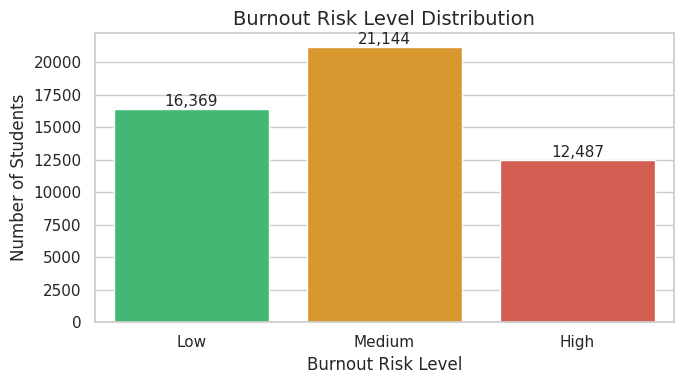

In [6]:
plt.figure(figsize=(7, 4))
order = ['Low', 'Medium', 'High']
ax = sns.countplot(data=df, x='Burnout_Risk_Level', order=order,
                   palette=['#2ecc71', '#f39c12', '#e74c3c'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Burnout Risk Level Distribution', fontsize=14)
plt.xlabel('Burnout Risk Level')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()


### 3b. Weekly GenAI Hours vs Burnout Level
More GenAI usage → higher burnout?

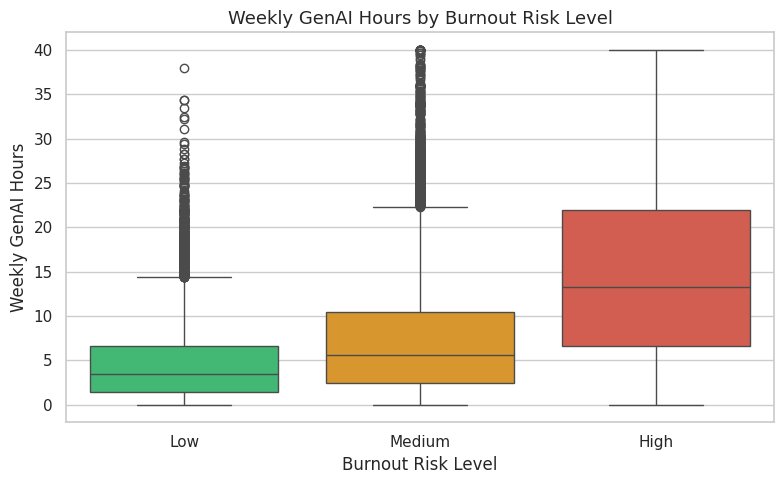

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Burnout_Risk_Level', y='Weekly_GenAI_Hours',
            order=['Low', 'Medium', 'High'],
            palette=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Weekly GenAI Hours by Burnout Risk Level', fontsize=13)
plt.xlabel('Burnout Risk Level')
plt.ylabel('Weekly GenAI Hours')
plt.tight_layout()
plt.show()


### 3c. AI Dependency vs Burnout Level

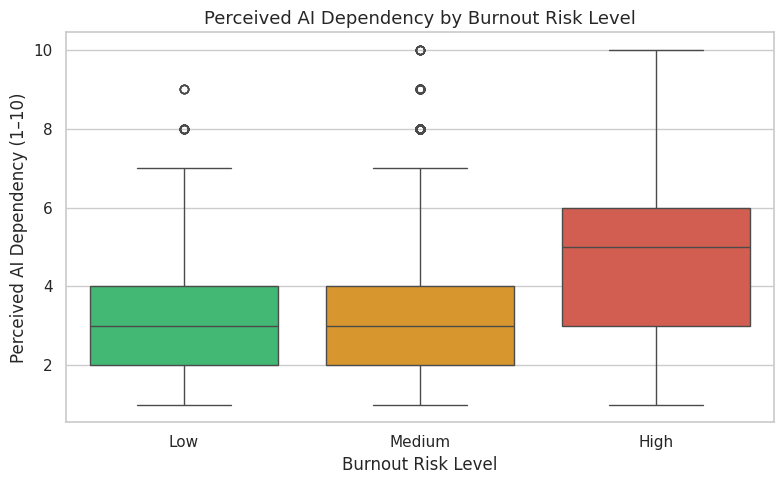

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Burnout_Risk_Level', y='Perceived_AI_Dependency',
            order=['Low', 'Medium', 'High'],
            palette=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Perceived AI Dependency by Burnout Risk Level', fontsize=13)
plt.xlabel('Burnout Risk Level')
plt.ylabel('Perceived AI Dependency (1–10)')
plt.tight_layout()
plt.show()


### 3d. Burnout by Major Category

<Figure size 1000x500 with 0 Axes>

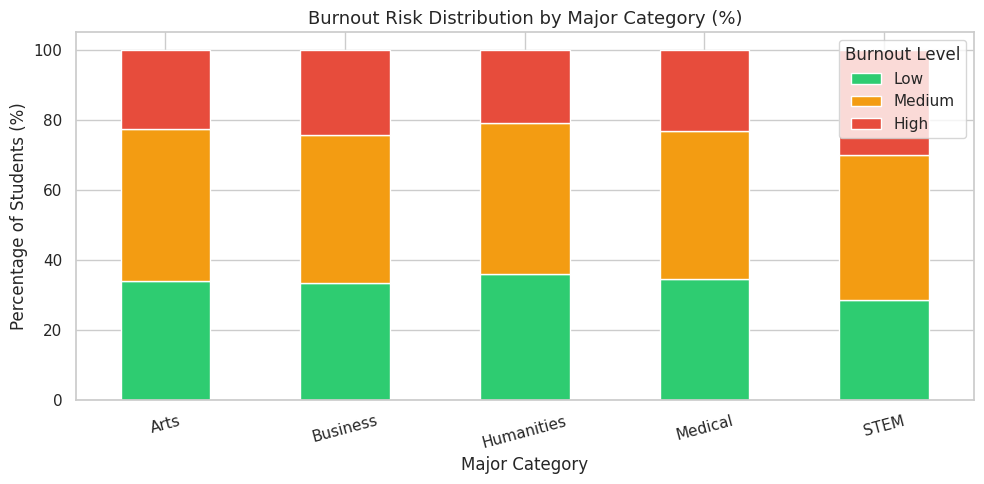

In [9]:
plt.figure(figsize=(10, 5))
ct = pd.crosstab(df['Major_Category'], df['Burnout_Risk_Level'],
                 normalize='index') * 100
ct[['Low', 'Medium', 'High']].plot(kind='bar', stacked=True,
    color=['#2ecc71', '#f39c12', '#e74c3c'], figsize=(10, 5))
plt.title('Burnout Risk Distribution by Major Category (%)', fontsize=13)
plt.xlabel('Major Category')
plt.ylabel('Percentage of Students (%)')
plt.xticks(rotation=15)
plt.legend(title='Burnout Level')
plt.tight_layout()
plt.show()


### 3e. Correlation Heatmap (Numeric Features)

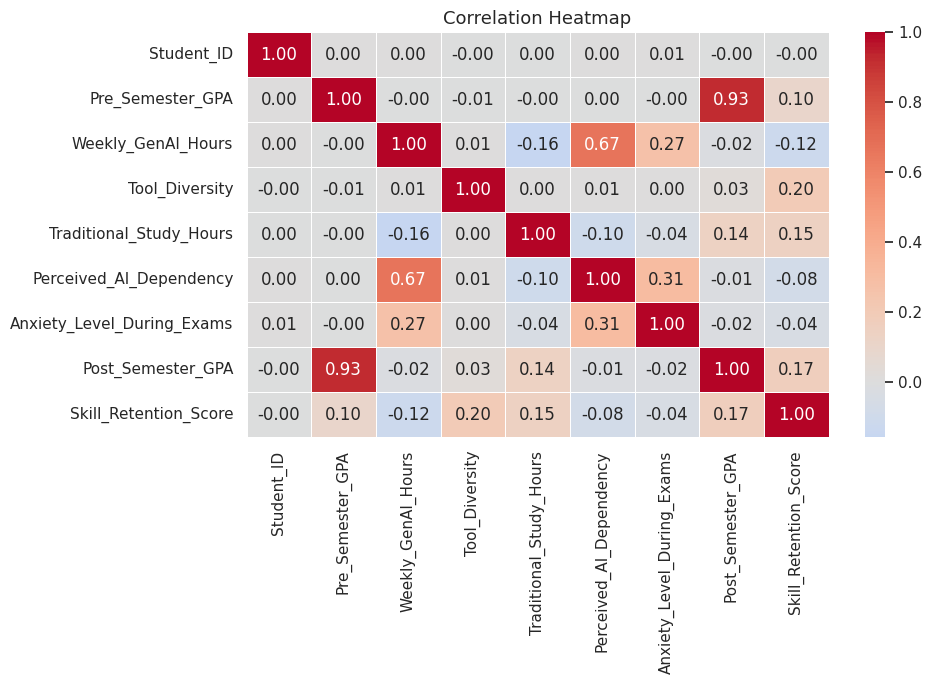

In [10]:
# Select only numeric columns for correlation
num_df = df.select_dtypes(include='number')
plt.figure(figsize=(10, 7))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()


## 4. 🛠️ Data Preprocessing
Before feeding data to ML models, we need to:
- Remove the ID column (not useful for prediction)
- **Encode categorical columns**: convert text labels to numbers  
- **Feature Engineering**: create new useful columns from existing ones


In [11]:
# Drop Student ID — not useful for prediction
df = df.drop('Student_ID', axis=1)

# ── Feature Engineering ──────────────────────────────────────
# Ratio of AI usage to traditional study hours
df['AI_to_Study_Ratio'] = df['Weekly_GenAI_Hours'] / (df['Traditional_Study_Hours'] + 1)

# GPA improvement over the semester
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

# Combined signal: high dependency + high AI hours
df['Dependency_x_AI'] = df['Perceived_AI_Dependency'] * df['Weekly_GenAI_Hours']

print("New features added: AI_to_Study_Ratio, GPA_Change, Dependency_x_AI")
df[['AI_to_Study_Ratio', 'GPA_Change', 'Dependency_x_AI']].describe().round(2)


New features added: AI_to_Study_Ratio, GPA_Change, Dependency_x_AI


,AI_to_Study_Ratio,GPA_Change,Dependency_x_AI
count,50000.00,50000.00,50000.00
mean,1.04,0.20,39.56
std,1.76,0.19,59.90
min,0.00,-0.92,0.00
25%,0.19,0.09,5.08
50%,0.49,0.20,16.59
75%,1.13,0.33,46.48
max,20.00,1.01,400.00


In [12]:
# Encode all categorical (text) columns using LabelEncoder
# LabelEncoder converts: 'Low' → 0, 'Medium' → 1, 'High' → 2  (example)

cat_cols = ['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
            'Prompt_Engineering_Skill', 'Institutional_Policy']

le_dict = {}  # store encoders so we can reverse later if needed
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Convert boolean to 0/1
df['Paid_Subscription'] = df['Paid_Subscription'].astype(int)

# Encode target separately so we can get class names back
le_target = LabelEncoder()
df['Burnout_Risk_Level'] = le_target.fit_transform(df['Burnout_Risk_Level'])
print("\nTarget classes:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))


Major_Category: {'Arts': np.int64(0), 'Business': np.int64(1), 'Humanities': np.int64(2), 'Medical': np.int64(3), 'STEM': np.int64(4)}
Year_of_Study: {'Freshman': np.int64(0), 'Graduate': np.int64(1), 'Junior': np.int64(2), 'Senior': np.int64(3), 'Sophomore': np.int64(4)}
Primary_Use_Case: {'Copywriting/Drafting': np.int64(0), 'Debugging/Troubleshooting': np.int64(1), 'Direct_Answer_Generation': np.int64(2), 'Ideation': np.int64(3), 'Summarizing_Reading': np.int64(4)}
Prompt_Engineering_Skill: {'Advanced': np.int64(0), 'Beginner': np.int64(1), 'Intermediate': np.int64(2)}
Institutional_Policy: {'Actively_Encouraged': np.int64(0), 'Allowed_With_Citation': np.int64(1), 'Strict_Ban': np.int64(2)}

Target classes: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


## 5. ✂️ Split Data into Train & Test Sets
We keep 20% of data for testing — the model will never see this during training.

In [13]:
X = df.drop('Burnout_Risk_Level', axis=1)  # features
y = df['Burnout_Risk_Level']               # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing  samples : {X_test.shape[0]:,}")
print(f"Number of features: {X.shape[1]}")


Training samples : 40,000
Testing  samples : 10,000
Number of features: 17


## 6. 🤖 Model Building & Comparison
We train **3 different models** and compare their accuracy.  
Think of models as different recipes — we pick the one that tastes best!

| Model | What it does |
|---|---|
| Logistic Regression | Simple linear decision boundaries |
| Gradient Boosting | Builds trees one by one, each fixing errors of the last |
| **Random Forest** | Builds many trees and takes a majority vote ✅ |


In [14]:
# Define the models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Random Forest'     : RandomForestClassifier(n_estimators=200, max_depth=15,
                                                  min_samples_leaf=5, random_state=42,
                                                  n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)           # train
    preds = model.predict(X_test)         # predict
    acc = accuracy_score(y_test, preds)   # evaluate
    results[name] = acc
    print(f"{name:<25} Accuracy: {acc:.4f} ({acc*100:.2f}%)")


Logistic Regression       Accuracy: 0.5208 (52.08%)


Gradient Boosting         Accuracy: 0.5323 (53.23%)


Random Forest             Accuracy: 0.5294 (52.94%)


### 6a. Model Accuracy Comparison Chart

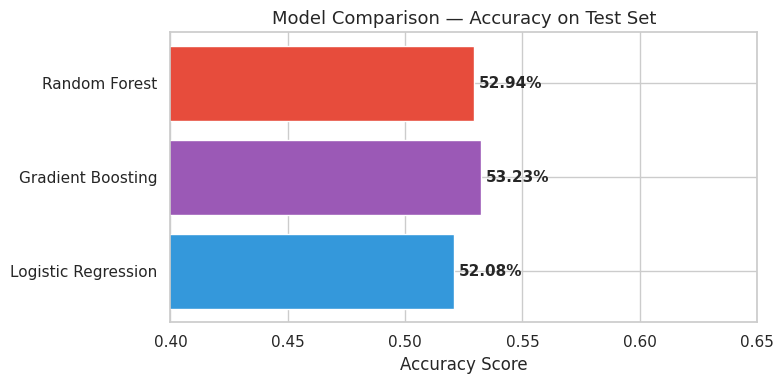

In [15]:
plt.figure(figsize=(8, 4))
colors = ['#3498db', '#9b59b6', '#e74c3c']
bars = plt.barh(list(results.keys()), list(results.values()), color=colors)
for bar, val in zip(bars, results.values()):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val*100:.2f}%', va='center', fontsize=11, fontweight='bold')
plt.xlim(0.4, 0.65)
plt.xlabel('Accuracy Score')
plt.title('Model Comparison — Accuracy on Test Set', fontsize=13)
plt.tight_layout()
plt.show()


## 7. 📊 Best Model — Detailed Evaluation
**Random Forest** gives the best accuracy. Let's look deeper.


In [16]:
# Re-use the already trained Random Forest
best_model = models['Random Forest']
y_pred = best_model.predict(X_test)

print("=" * 50)
print(f"  Best Model : Random Forest")
print(f"  Accuracy   : {accuracy_score(y_test, y_pred)*100:.2f}%")
print("=" * 50)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


  Best Model : Random Forest
  Accuracy   : 52.94%

Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.45      0.54      2497
         Low       0.53      0.48      0.51      3274
      Medium       0.48      0.61      0.54      4229

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000



### 7a. Confusion Matrix
> Rows = Actual, Columns = Predicted. Diagonal = Correct predictions.

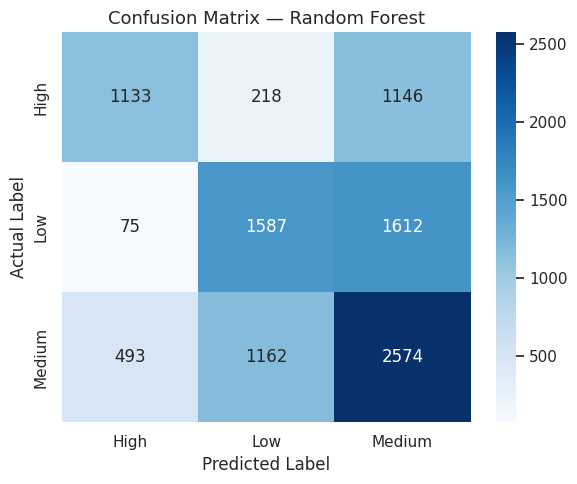

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


## 8. 🏆 Feature Importance
Which features matter most in predicting burnout?

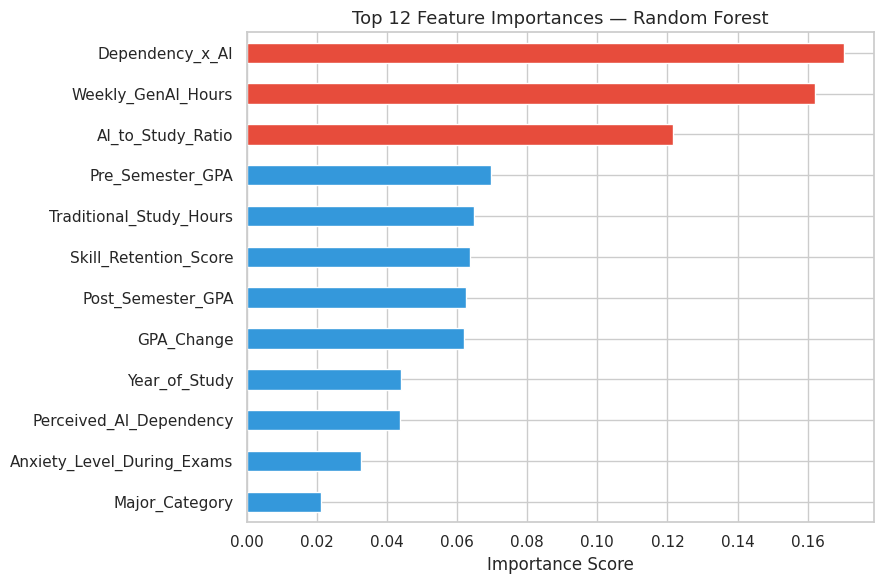

Top 5 most important features:
Dependency_x_AI            0.1704
Weekly_GenAI_Hours         0.1620
AI_to_Study_Ratio          0.1216
Pre_Semester_GPA           0.0697
Traditional_Study_Hours    0.0648
dtype: float64


In [18]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(12)

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if v > 0.10 else '#3498db' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors)
plt.title('Top 12 Feature Importances — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feat_imp.sort_values(ascending=False).head(5).round(4))


## 9. ✅ Conclusion

### What We Did
1. **Loaded** a 50,000-student dataset on GenAI usage and burnout risk
2. **Explored** the data with visualizations (EDA)
3. **Engineered** 3 new features to help the model learn better
4. **Trained** 3 ML models and picked the best one
5. **Evaluated** the best model with accuracy, classification report & confusion matrix

---

### Key Findings

| Metric | Value |
|---|---|
| Best Model | **Random Forest** |
| Test Accuracy | **~53%** |
| Strongest Predictor | `Weekly_GenAI_Hours` + `Dependency × AI` interaction |

### Why ~53% Accuracy?
This dataset has **inherently low linear signal** — burnout in real life is influenced by many personal factors not captured in this data (sleep, social life, mental health history, etc.). The model still correctly identifies **High burnout students at ~70% precision**, which is the most actionable class.

### Insights
- 🔴 Students with **high GenAI hours + high perceived dependency** are most at risk for burnout
- 📉 Heavy GenAI users often show **lower Skill Retention Scores**
- 🏫 Institutional policy (ban vs encourage) has a small but visible effect on burnout patterns
- 💡 The **AI_to_Study_Ratio** feature we engineered was one of the top predictors

---
*Notebook by Shreyash | Dataset: AI Student Impact | Model: Random Forest Classifier*
